In [74]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
 
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import LabelEncoder 
 
import scipy.stats as stats 

from sklearn.preprocessing import LabelEncoder, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings 
warnings.filterwarnings('ignore') 

In [75]:
df = pd.read_excel("output1.xlsx")
df

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,False,B,118221
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,False,B,118221
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,False,B,118221
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,False,B,118221


In [76]:
n_data = df.copy()

In [77]:
n_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday_x   421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  IsHoliday_y   421570 non-null  bool          
 15  Type          421

In [78]:
n_data.drop(['IsHoliday_x'], axis=1, inplace = True)

In [79]:
n_data.head(3)

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315


In [80]:
n_data.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'IsHoliday_y', 'Type', 'Size'],
      dtype='object')

In [81]:
# Encoding categorical variables
label_encoder = LabelEncoder()
n_data['IsHoliday_y'] = label_encoder.fit_transform(n_data['IsHoliday_y'])
n_data['Type'] = label_encoder.fit_transform(n_data['Type'])

In [82]:
n_data.head(3)

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0,0,151315
1,1,1,2010-02-12,46039.49,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,1,0,151315
2,1,1,2010-02-19,41595.55,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,0,0,151315


In [83]:
n_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   Temperature   421570 non-null  float64       
 5   Fuel_Price    421570 non-null  float64       
 6   MarkDown1     150681 non-null  float64       
 7   MarkDown2     111248 non-null  float64       
 8   MarkDown3     137091 non-null  float64       
 9   MarkDown4     134967 non-null  float64       
 10  MarkDown5     151432 non-null  float64       
 11  CPI           421570 non-null  float64       
 12  Unemployment  421570 non-null  float64       
 13  IsHoliday_y   421570 non-null  int64         
 14  Type          421570 non-null  int64         
 15  Size          421

In [84]:
n_data.drop(['Date'], axis=1, inplace = True)

In [85]:
n_data.drop(['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5'], axis=1, inplace = True)

In [86]:
y = n_data['Weekly_Sales']
X = n_data.drop(columns=['Weekly_Sales'])
import statsmodels.api as sm
sm.add_constant(X)

,const,Store,Dept,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday_y,Type,Size
0,1.0,1,1,42.31,2.572,211.096358,8.106,0,0,151315
1,1.0,1,1,38.51,2.548,211.242170,8.106,1,0,151315
2,1.0,1,1,39.93,2.514,211.289143,8.106,0,0,151315
3,1.0,1,1,46.63,2.561,211.319643,8.106,0,0,151315
4,1.0,1,1,46.50,2.625,211.350143,8.106,0,0,151315
...,...,...,...,...,...,...,...,...,...,...
421565,1.0,45,98,64.88,3.997,192.013558,8.684,0,1,118221
421566,1.0,45,98,64.89,3.985,192.170412,8.667,0,1,118221
421567,1.0,45,98,54.47,4.000,192.327265,8.667,0,1,118221
421568,1.0,45,98,56.47,3.969,192.330854,8.667,0,1,118221


In [87]:
scaler = StandardScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display first 5 rows
print(X_scaled.head())

      Store      Dept  Temperature  Fuel_Price       CPI  Unemployment  \
0 -1.658199 -1.418742    -0.963798   -1.720834  1.018774      0.078201   
1 -1.658199 -1.418742    -1.169783   -1.773177  1.022498      0.078201   
2 -1.658199 -1.418742    -1.092810   -1.847330  1.023697      0.078201   
3 -1.658199 -1.418742    -0.729625   -1.744825  1.024476      0.078201   
4 -1.658199 -1.418742    -0.736672   -1.605243  1.025255      0.078201   

   IsHoliday_y      Type      Size  
0    -0.275106 -0.885307  0.239209  
1     3.634961 -0.885307  0.239209  
2    -0.275106 -0.885307  0.239209  
3    -0.275106 -0.885307  0.239209  
4    -0.275106 -0.885307  0.239209  


In [88]:
# Calculating VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]

# Display VIF values
print(vif_data)

        Feature       VIF
0         Store  1.124887
1          Dept  1.000632
2   Temperature  1.136801
3    Fuel_Price  1.085890
4           CPI  1.243291
5  Unemployment  1.197013
6   IsHoliday_y  1.029633
7          Type  3.058348
8          Size  2.982955


<Axes: >

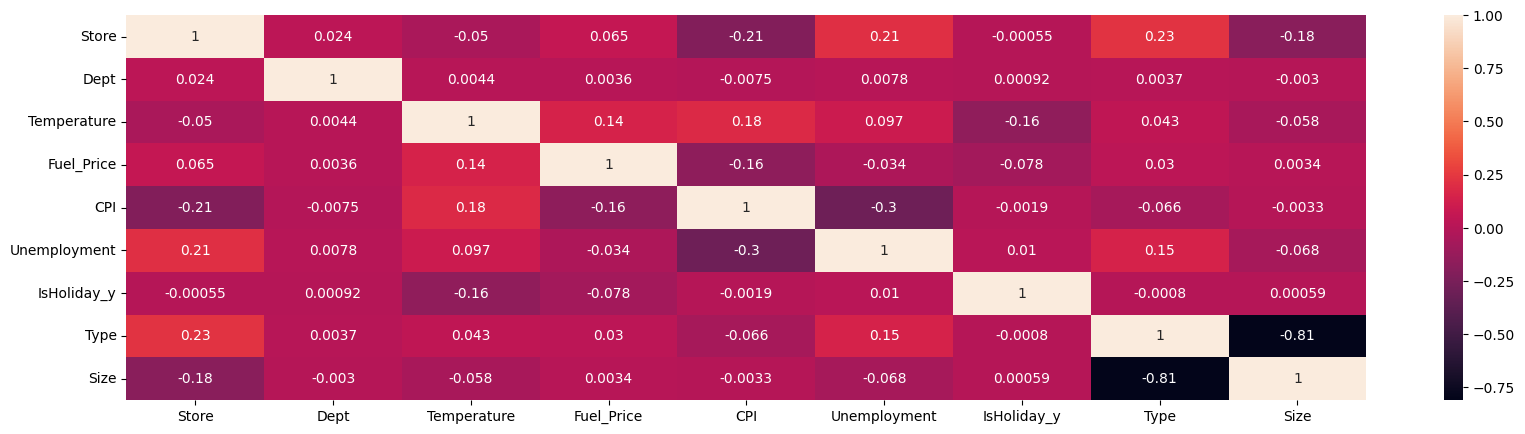

In [89]:
plt.figure(figsize=[20,5])
sns.heatmap(X_scaled.corr(), annot = True)

<Axes: >

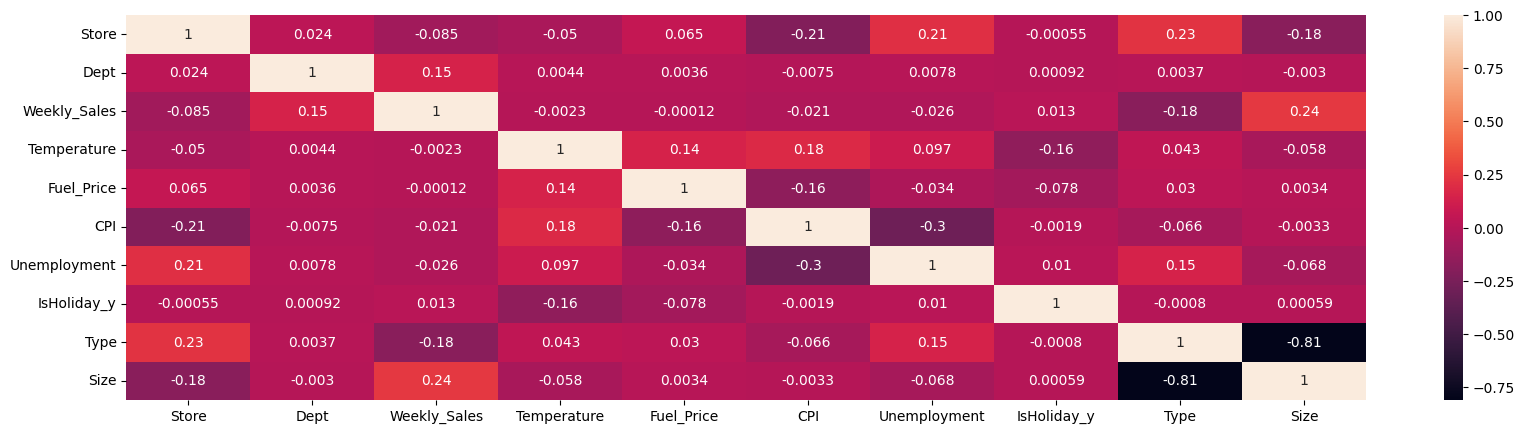

In [90]:
plt.figure(figsize=[20,5])
sns.heatmap(n_data.corr(), annot = True)

In [91]:
# Step 3: Split Data into Train & Test Sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 4: Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 5: Make Predictions
y_pred = model.predict(X_test)

# Step 6: Evaluate the Model
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Display Results
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.0879
RMSE: 21809.2914


In [92]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Apply Polynomial Features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_train)

# Train Model
model = LinearRegression()
model.fit(X_poly, y_train)

# Predict & Evaluate
y_pred = model.predict(poly.transform(X_test))
print("New R² Score:", r2_score(y_test, y_pred))


New R² Score: 0.20814289663045615


In [93]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5)
lasso.fit(X_train, y_train)

# Keep only important features
important_features = X.columns[lasso.coef_ != 0]
print("Selected Features:", important_features.tolist())


Selected Features: ['Store', 'Dept', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'IsHoliday_y', 'Type', 'Size']


In [95]:
from sklearn.ensemble import RandomForestRegressor

# Train with optimized settings
rf = RandomForestRegressor(n_estimators=20, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predict & Evaluate
y_pred = rf.predict(X_test)
print("Random Forest R² Score:", r2_score(y_test, y_pred))


Random Forest R² Score: 0.8646054491762055


In [99]:
from sklearn.ensemble import RandomForestRegressor

# Train with optimized settings
rf = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predict & Evaluate
y_pred = rf.predict(X_test)
print("Random Forest R² Score:", r2_score(y_test, y_pred))


Random Forest R² Score: 0.9248137044517504


In [ ]:
# n_data_sample = n_data.sample(frac=0.1, random_state=42)  # Use 10% data


In [101]:
# from sklearn.ensemble import RandomForestRegressor

# rf = RandomForestRegressor(n_estimators=100, random_state=42)
# rf.fit(X_train, y_train)

# y_pred = rf.predict(X_test)
# print("Random Forest R² Score:", r2_score(y_test, y_pred))


In [98]:

from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=50, max_depth=10, learning_rate=0.1, n_jobs=-1)
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
print("XGBoost R² Score:", r2_score(y_test, y_pred))


   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/150.0 MB 419.4 kB/s eta 0:05:57
   ---------------------------------------- 0.5/150.0 MB 419.4 kB/s eta 0:05:57
   ---------------------------------------- 0.5/150.0 MB 419.4 kB/s eta 0:05:57
   ---------------------------------------- 0.8/150.0 MB 435.8 kB/s eta 0:05:43
   ---------------------------------------- 0.8/150.0 MB 435.8 kB/s eta 0:05:43
   ---------------------------------------- 1.0/150.0 MB 508.4 kB/s eta 0:04:53
   ---------------------------------------- 1.0/150.0 MB 508.4 kB/s eta 0:04:53
   -----------


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


XGBoost R² Score: 0.9246700433186881


In [100]:


# Apply Polynomial Features
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

# Train Model
model = LinearRegression()
model.fit(X_poly_train, y_train)

# Predict
y_train_pred = model.predict(X_poly_train)
y_test_pred = model.predict(X_poly_test)

# Evaluate
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Polynomial Regression - Train R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")



Polynomial Regression - Train R²: 0.2036, Test R²: 0.2081


In [103]:
from sklearn.ensemble import RandomForestRegressor

# Train Model
rf = RandomForestRegressor(n_estimators=40, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predict
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# Evaluate
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Random Forest - Train R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")


Random Forest - Train R²: 0.8795, Test R²: 0.8650
